# <span style="color:green"> Lecture 06 notebook </span>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## <span style="color:blue">  Exercise 06.1 </span>

Per prima cosa, è stato implementato all'interno di NSL_SIMULATOR l'algoritmo di Gibbs. Questo algoritmo modifica il valore di uno spin $s_k$ secondo la probabilità:

$$p(s'_k = \pm 1 | \{s_j : j \neq k\}) = \frac{1}{1 + \exp\left(\mp 2 \beta J \sum_{i (n.n. to k)} s_i\right)}$$

Per l'esercizio è stato adoperato uno script python. 

Si è partiti dalla temperatura più alta, $T = 2.0$, riducendola ogni volta di $0.1$ fino ad arrivare alla temperatura minima $T= 0.5$.

Prima di ogni misura, il sistema subisce $100000$ step di termalizzazione.
A quel punto partono le misure, articolate in $20$ blocchi da $100000$ passi ciascuno.
Escludendo il primo valore di temperatura, per tutti gli altri si è utilizzata come configurazione di partenza per l'equilibrazione la configurazione finale della temperatura precedente.


Nelle figure sottostanti sono riportati due grafici relativi all'equilibrazione dell'energia totale per particella $U/N$ con i due algoritmi utilizzati per l'evoluzione del sistema, Metropolis e algoritmo di Gibbs, ai due valori estremi di $T$.

Possiamo notare come a temperaura alta ($T=2.0$) l'equilibrazione è molto rapida, mentre a temperatura più bassa ($T=0.5$), il sistema richiede decisamente più tempo per raggiungere l'equilibrio indipendentemente dall'algoritmo utilizzato.

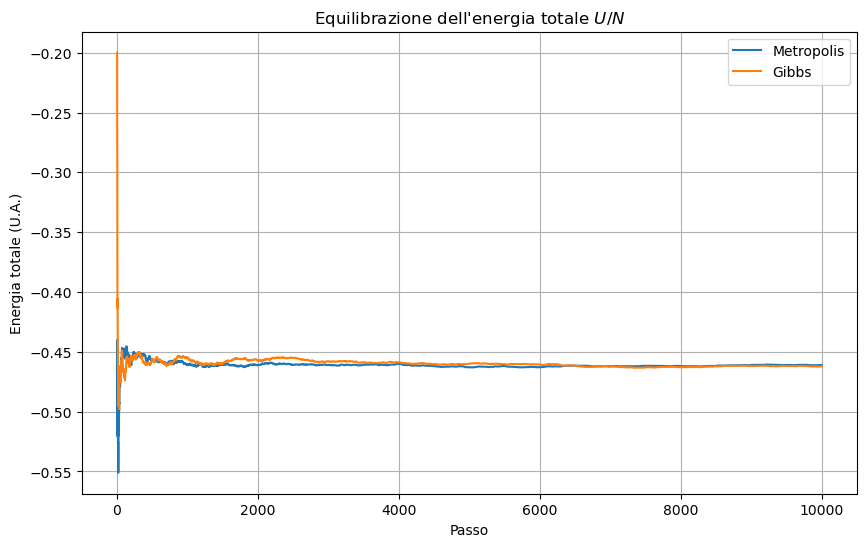

In [41]:
plt.figure(figsize=(10, 6))

blocks, energy = np.loadtxt(f"Exercise_06.1/total_energy_equil_M_2.0.dat", usecols = (0, 2), unpack = True)
plt.plot(blocks, energy, label = "Metropolis")
energy = np.loadtxt(f"Exercise_06.1/total_energy_equil_G_2.0.dat", usecols = (2), unpack = True)
plt.plot(blocks, energy, label = "Gibbs")
plt.title("Equilibrazione dell'energia totale $U/N$")
plt.xlabel("Passo")
plt.ylabel("Energia totale (U.A.)")
plt.grid(True)
plt.legend()

plt.plot();



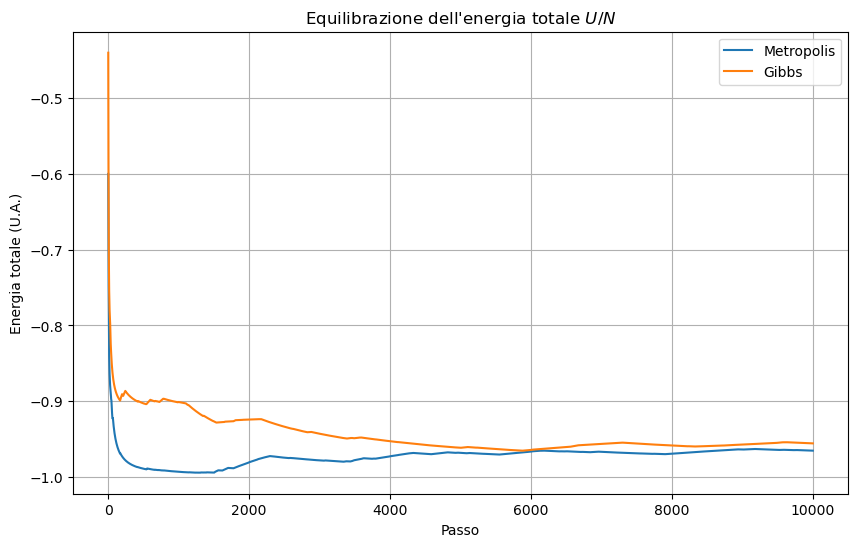

In [40]:
plt.figure(figsize=(10, 6))

blocks, energy = np.loadtxt(f"Exercise_06.1/total_energy_equil_M_0.5.dat", usecols = (0, 2), unpack = True)
plt.plot(blocks, energy, label = "Metropolis")
energy = np.loadtxt(f"Exercise_06.1/total_energy_equil_G_0.5.dat", usecols = (2), unpack = True)
plt.title("Equilibrazione dell'energia totale $U/N$")
plt.plot(blocks, energy, label = "Gibbs")
plt.xlabel("Passo")
plt.ylabel("Energia totale (U.A.)")
plt.grid(True)
plt.legend()

plt.plot();

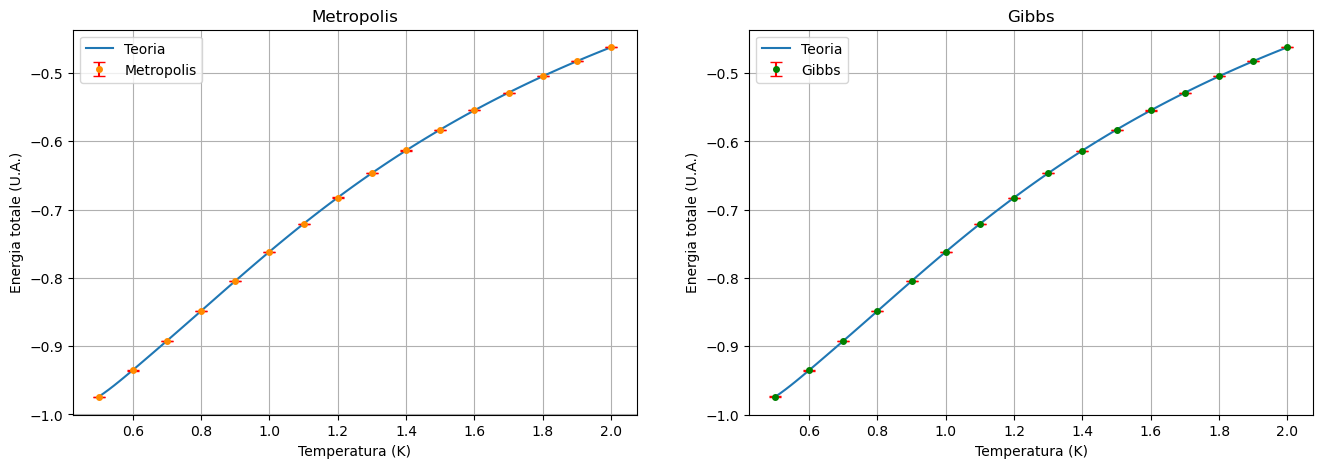

In [8]:
temperatures = np.arange(0.5, 2.1, 0.1)

final_energy = []
final_energy_err = []
final_energy_G = []
final_energy_G_err = []

for i, t in enumerate(temperatures):
    energy, error_e = np.loadtxt(f"Exercise_06.1/total_energy_Metro_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    energy_G, error_e_G = np.loadtxt(f"Exercise_06.1/total_energy_Gibbs_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_energy.append(energy[-1])
    final_energy_err.append(error_e[-1])
    final_energy_G.append(energy_G[-1])
    final_energy_G_err.append(error_e_G[-1])

points=100
T = np.linspace(0.5,2.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(T, e, label = "Teoria")
axes[0].errorbar(temperatures, final_energy, yerr=final_energy_err, fmt='o', color='darkorange', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Metropolis")
axes[0].set_title("Metropolis")
axes[0].set_xlabel("Temperatura (K)")
axes[0].set_ylabel("Energia totale (U.A.)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T, e, label = "Teoria")
axes[1].errorbar(temperatures, final_energy_G, yerr=final_energy_G_err, fmt='o', color='green', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Gibbs")
axes[1].set_title("Gibbs")
axes[1].set_xlabel("Temperatura (K)")
axes[1].set_ylabel("Energia totale (U.A.)")
axes[1].grid(True)
axes[1].legend()

plt.show()

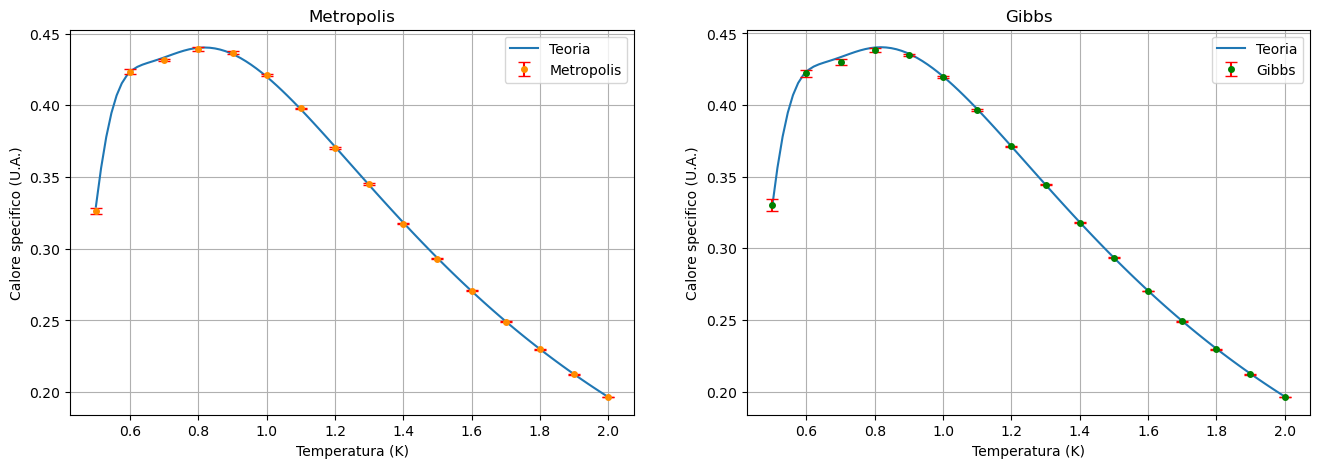

In [9]:
final_cv = []
final_cv_err = []
final_cv_G = []
final_cv_G_err = []


for i, t in enumerate(temperatures):
    cv, error_cv = np.loadtxt(f"Exercise_06.1/specific_heat_Metro_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    cv_G, error_cv_G = np.loadtxt(f"Exercise_06.1/specific_heat_Gibbs_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_cv.append(cv[-1])
    final_cv_err.append(error_cv[-1])
    final_cv_G.append(cv_G[-1])
    final_cv_G_err.append(error_cv_G[-1])

heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(T, heat, label = "Teoria")
axes[0].errorbar(temperatures, final_cv, yerr=final_cv_err, fmt='o', color='darkorange', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Metropolis")
axes[0].set_title("Metropolis")
axes[0].set_xlabel("Temperatura (K)")
axes[0].set_ylabel("Calore specifico (U.A.)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T, heat, label = "Teoria")
axes[1].errorbar(temperatures, final_cv_G, yerr=final_cv_G_err, fmt='o', color='green', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Gibbs")
axes[1].set_title("Gibbs")
axes[1].set_xlabel("Temperatura (K)")
axes[1].set_ylabel("Calore specifico (U.A.)")
axes[1].grid(True)
axes[1].legend()

plt.show()

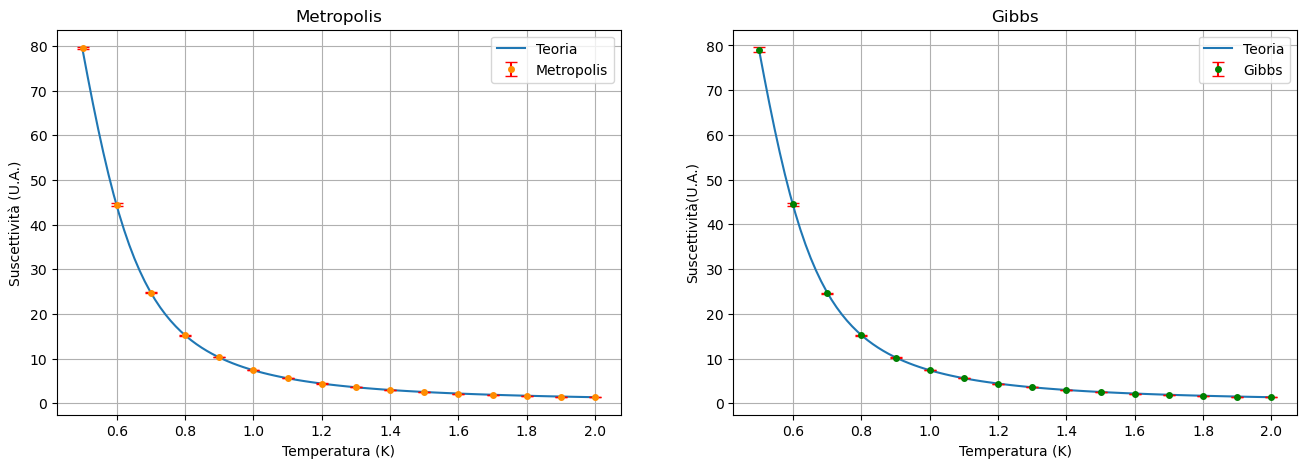

In [10]:
final_chi = []
final_chi_err = []
final_chi_G = []
final_chi_G_err = []

for i, t in enumerate(temperatures):
    chi, error_chi = np.loadtxt(f"Exercise_06.1/susceptibility_Metro_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_chi.append(chi[-1])
    final_chi_err.append(error_chi[-1])
    chi, error_chi = np.loadtxt(f"Exercise_06.1/susceptibility_Gibbs_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_chi_G.append(chi[-1])
    final_chi_G_err.append(error_chi[-1])

X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(T, X, label = "Teoria")
axes[0].errorbar(temperatures, final_chi, yerr=final_chi_err, fmt='o', color='darkorange', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Metropolis")
axes[0].set_title("Metropolis")
axes[0].set_xlabel("Temperatura (K)")
axes[0].set_ylabel("Suscettività (U.A.)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T, X, label = "Teoria")
axes[1].errorbar(temperatures, final_chi_G, yerr=final_chi_G_err, fmt='o', color='green', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Gibbs")
axes[1].set_title("Gibbs")
axes[1].set_xlabel("Temperatura (K)")
axes[1].set_ylabel("Suscettività(U.A.)")
axes[1].grid(True)
axes[1].legend()

plt.show()

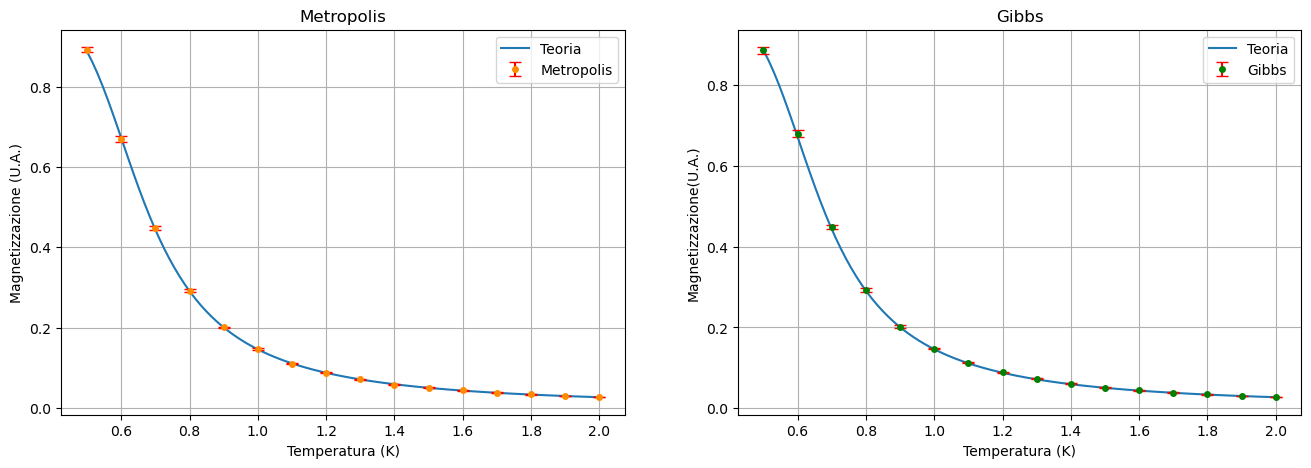

In [55]:
final_M = []
final_M_err = []
final_M_G = []
final_M_G_err = []


for i, t in enumerate(temperatures):
    M, error_M = np.loadtxt(f"Exercise_06.1/magnetization_Metro_h02_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    M_G, error_M_G = np.loadtxt(f"Exercise_06.1/magnetization_Gibbs_h02_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_M.append(M[-1])
    final_M_err.append(error_M[-1])
    final_M_G.append(M_G[-1])
    final_M_G_err.append(error_M_G[-1])

h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(T, M, label = "Teoria")
axes[0].errorbar(temperatures, final_M, yerr=final_M_err, fmt='o', color='darkorange', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Metropolis")
axes[0].set_title("Metropolis")
axes[0].set_xlabel("Temperatura (K)")
axes[0].set_ylabel("Magnetizzazione (U.A.)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T, M, label = "Teoria")
axes[1].errorbar(temperatures, final_M_G, yerr=final_M_G_err, fmt='o', color='green', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Gibbs")
axes[1].set_title("Gibbs")
axes[1].set_xlabel("Temperatura (K)")
axes[1].set_ylabel("Magnetizzazione(U.A.)")
axes[1].grid(True)
axes[1].legend()

plt.show()

Notiamo che per entrambi i metodi di campionamento, i valori calcolati concordano esattamente con la teoria.

Con $100$ blocchi da $10000$ passi ciascuno, il $C_v$ calcolato con Gibbs risulta sottostimato.

0.9869497169342516


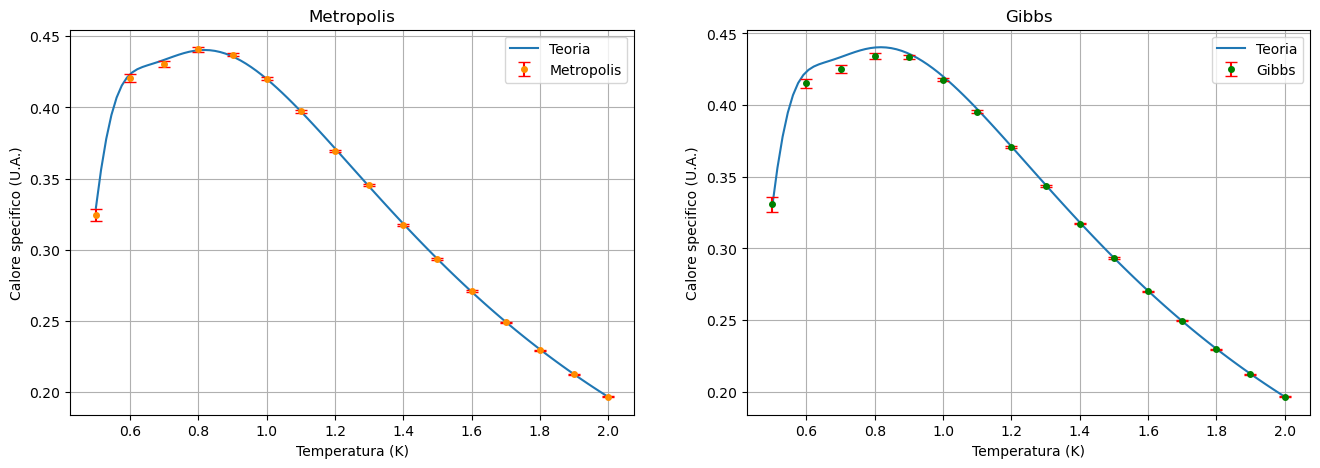

In [76]:
final_cv = []
final_cv_err = []
final_cv_G = []
final_cv_G_err = []


for i, t in enumerate(temperatures):
    cv, error_cv = np.loadtxt(f"Gibbs_problem/specific_heat_Metro_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    cv_G, error_cv_G = np.loadtxt(f"Gibbs_problem/specific_heat_Gibbs_h0_{t:.1f}.dat", usecols = (2, 3), unpack = True)
    final_cv.append(cv[-1])
    final_cv_err.append(error_cv[-1])
    final_cv_G.append(cv_G[-1])
    final_cv_G_err.append(error_cv_G[-1])
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(T, heat, label = "Teoria")
axes[0].errorbar(temperatures, final_cv, yerr=final_cv_err, fmt='o', color='darkorange', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Metropolis")
axes[0].set_title("Metropolis")
axes[0].set_xlabel("Temperatura (K)")
axes[0].set_ylabel("Calore specifico (U.A.)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T, heat, label = "Teoria")
axes[1].errorbar(temperatures, final_cv_G, yerr=final_cv_G_err, fmt='o', color='green', capsize=4, elinewidth=1.5, markersize=4, ecolor='red', label = "Gibbs")
axes[1].set_title("Gibbs")
axes[1].set_xlabel("Temperatura (K)")
axes[1].set_ylabel("Calore specifico (U.A.)")
axes[1].grid(True)
axes[1].legend()

rel_err = final_cv_G[2]/final_cv[2]
print(rel_err)

plt.show()

L'unica cosa che mi viene in mente è che a queste temperature il sistema ha larghi blocchi di spin allineati tra loro. All'interfaccia, Metropolis cambia con probabilità $1$ perché il $\Delta E$ è nullo, mentre Gibbs cambia con probabilità $0.5$. Quetso potrebbe portare a una varianza dell'energia media più bassa, e quindi a una sottostima del calore specifico. 

Ho notato che il valore non si corregge all'aumentare del numero di blocchi, ma all'aumentare della lunghezza degli stessi. Questo mi fa pensare che probabilmente, vista la natura di varianza del calore specifico, utilizzare blocchi troppo corti potrebbe tenere in considerazione valori ancora troppo correlati, sottostimandola. Per questo motivo, ho studiato autocorrelazione dell'energia totale del sistema coi due metodi di campionamento.

Tempo di correlazione integrato (Area): 24.23


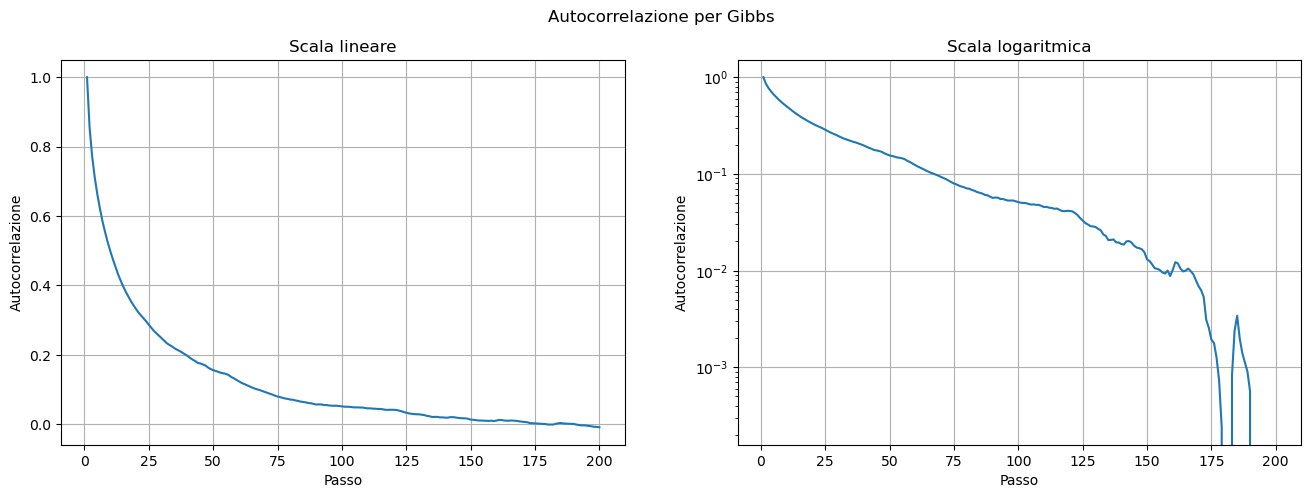

In [77]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

block, energy = np.loadtxt("Gibbs_problem/total_energy_Gibbs_0.7.dat", usecols = (0, 1), unpack = True)

tmax = len(block)
chi_MC = []

max_lag = 200;

denominator = 1/tmax * np.sum(energy[:(tmax)]*energy[:(tmax)]) - (1/tmax*np.sum(energy[:(tmax)]))**2

for i in range (max_lag):
    upper_limit = tmax - i
    norm = 1/upper_limit

    first_term = norm*np.sum(energy[:upper_limit]*energy[i:(tmax)])
    second_term = norm*np.sum(energy[:upper_limit])*norm*np.sum(energy[i:(tmax)])

    chi_MC.append((first_term - second_term)/denominator)



axes[0].plot(block[:max_lag], chi_MC)
axes[0].grid(True)
axes[0].set_title("Scala lineare")
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("Autocorrelazione")


axes[1].plot(block[:max_lag], chi_MC)
axes[1].grid(True)
axes[1].set_yscale('log')
axes[1].set_title("Scala logaritmica")
axes[1].set_xlabel("Passo")
axes[1].set_ylabel("Autocorrelazione")

tau_int = 0.5 + np.sum(chi_MC[:max_lag])
print(f"Tempo di correlazione integrato (Area): {tau_int:.2f}")

plt.suptitle("Autocorrelazione per Gibbs")
plt.show()

Tempo di correlazione integrato (Area): 17.64


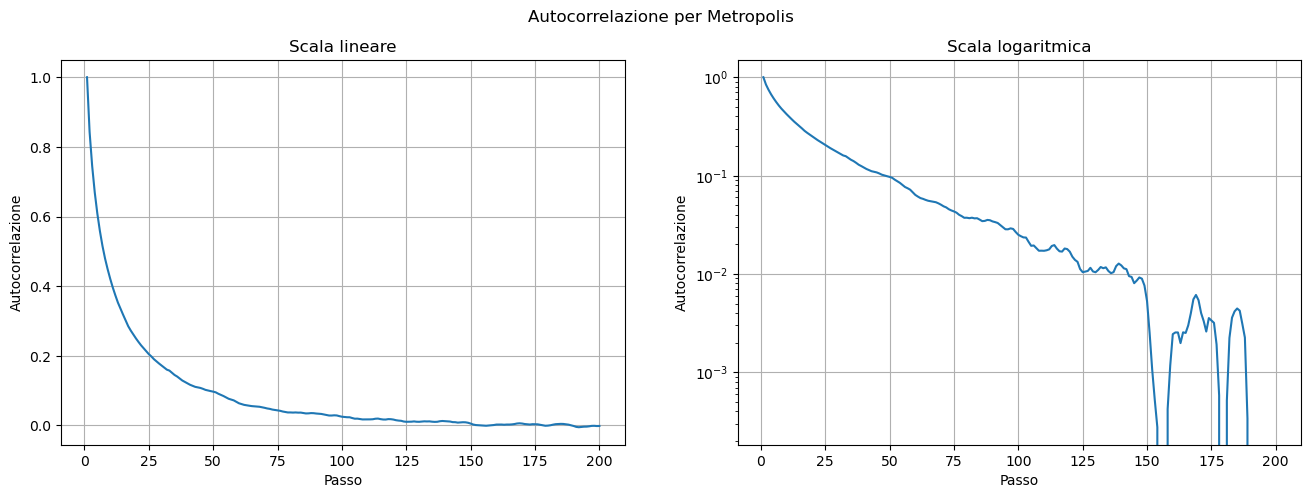

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

block, energy = np.loadtxt("Gibbs_problem/total_energy_Metro_0.7.dat", usecols = (0, 1), unpack = True)

tmax = len(block)
chi_MC = []

max_lag = 200;

denominator = 1/tmax * np.sum(energy[:(tmax)]*energy[:(tmax)]) - (1/tmax*np.sum(energy[:(tmax)]))**2

for i in range (max_lag):
    upper_limit = tmax - i
    norm = 1/upper_limit

    first_term = norm*np.sum(energy[:upper_limit]*energy[i:(tmax)])
    second_term = norm*np.sum(energy[:upper_limit])*norm*np.sum(energy[i:(tmax)])

    chi_MC.append((first_term - second_term)/denominator)



axes[0].plot(block[:max_lag], chi_MC)
axes[0].grid(True)
axes[0].set_title("Scala lineare")
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("Autocorrelazione")


axes[1].plot(block[:max_lag], chi_MC)
axes[1].grid(True)
axes[1].set_yscale('log')
axes[1].set_title("Scala logaritmica")
axes[1].set_xlabel("Passo")
axes[1].set_ylabel("Autocorrelazione")

tau_int = 0.5 + np.sum(chi_MC[:max_lag])
print(f"Tempo di correlazione integrato (Area): {tau_int:.2f}")

plt.suptitle("Autocorrelazione per Metropolis")
plt.show()

L'autocorrelazione sembra in effetti un po' più lenta a decrescere per Gibbs, ma non così significativamente. Probabilmente allora c'è qualche fenomeno raro che non riesco a comprendere nei miei blocchi a meno di non allungarne di molto la lunghezza.